<a href="https://colab.research.google.com/github/ebrarkuz/Bus-Reservation-System-/blob/main/student_draft_completed_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BBM418 / AIN433 — Fundamentals of Computer Vision  
## Programming Assignment 2: Object Localization and Single-Object Tracking

### Student Notebook

This notebook is the starter template for the assignment. This is a draft.
You can follow the given structure or you can implement your version.
Feel free to change given code templates.

The assignment has five main parts:

1. Dataset loading and visualization  
2. Search-region sample generation  
3. CNN-based bounding-box regression model  
4. Single-object tracking on validation and test sequences  
5. Validation evaluation and analysis  

Keep your implementation clean, reproducible, and easy to follow.

### Student Info

#### Name: Ebrar Pınar Kuz

#### ID: 2220765017

## Assignment Setting

You will work with the given single-object tracking dataset.

### Training and Validation Sequences

These contain full ground-truth annotations:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  groundtruth_rect.txt
```

### Test Sequences

These contain only the first-frame initialization box:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  init_rect.txt
```

## Important Rule

For validation and test tracking, you may use only the first-frame bounding box to initialize the tracker.

After the first frame, all bounding boxes must be predicted by your tracker.

For validation sequences, later ground-truth boxes may be used **only after tracking** to compute evaluation metrics.

For test sequences, ground truth is hidden and must not be used.

## Expected Output

Your notebook should generate prediction CSV files for the test sequences.

Each file must be saved as:

```text
outputs/test/<sequence_name>_predictions.csv
```

The required CSV format is:

```text
frame,x,y,w,h
1,198,214,34,81
2,197.2,214.1,34.5,80.7
3,195.4,213.9,34.8,81.2
```

Coordinates must be full-frame pixel coordinates in `(x, y, width, height)` format. Do **not** save normalized crop coordinates.

# 0. Imports and Configuration

Run this section first. You may add extra imports if needed.

Make sure the paths below match your local folder structure.

In [ ]:
import os
import csv
import math
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

In Google Colab environment, to download the dataset and extract it to the working directory you may use the following cell.

In [ ]:
# 1. Configuration
FILE_ID = '1q8AAAQ64QwA16gU5jEKDvPure7CVajUt'
ZIP_NAME = 'dataset.zip'

# 2. Download the file
!gdown --id {FILE_ID} -O {ZIP_NAME}

# 3. Extract directly to /content
# This will result in: /content/data/sequences/ and /content/data/splits/
!unzip -q {ZIP_NAME} -d /content/

# 4. Cleanup the zip file
!rm {ZIP_NAME}

# 5. Verify the structure
print("Files in /content/data:", os.listdir("/content/data"))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1q8AAAQ64QwA16gU5jEKDvPure7CVajUt
From (redirected): https://drive.google.com/uc?id=1q8AAAQ64QwA16gU5jEKDvPure7CVajUt&confirm=t&uuid=5a23c09b-b6d3-433e-ac82-309794bf9fa6
To: /content/dataset.zip
100% 1.64G/1.64G [00:12<00:00, 136MB/s]
Files in /content/data: ['splits', 'sequences']


## Reproducibility

Set random seeds so your results are more reproducible.
Include your seeds if you introduce additional randomness.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Paths and Hyperparameters

Update `DATA_ROOT` if your dataset is located somewhere else.

The suggested hyperparameters are only starting points. You may change them, but report your final choices in the discussion section.

In [ ]:
DATA_ROOT = Path("data/sequences")  # TODO: Change this if necessary
SPLIT_ROOT = Path("data/splits")
OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
SEARCH_SCALE = 3
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 5e-5
NUM_WORKERS = 0

print("Device:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)

Device: cuda
DATA_ROOT: data/sequences


# PART 1 — Dataset Loading and Visualization

In this part, you will implement utilities for loading the dataset and visualizing bounding boxes.

You need separate loading functions for:

- training/validation sequences with `groundtruth_rect.txt`,
- test sequences with `init_rect.txt`.

This distinction is important because test sequences do not contain full ground truth.

## 1.1 Bounding-Box File Reader

The annotation files contain bounding boxes in the format:

```text
x,y,width,height
```

Some files may use commas, spaces, or tabs as separators. Your parser should handle these cases.

In [ ]:
def read_bbox_file(path: Path) -> np.ndarray:
    """
    Read a bounding-box file.

    The file may contain one line or multiple lines.
    Each line has:
        x, y, width, height

    The parser should handle comma-separated, tab-separated,
    and whitespace-separated values.

    Returns:
        bboxes: numpy array of shape (N, 4)
    """
    bboxes = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Replace commas and tabs with spaces, then split
            parts = line.replace(",", " ").replace("\t", " ").split()
            if len(parts) >= 4:
                bboxes.append([float(p) for p in parts[:4]])
    return np.array(bboxes, dtype=np.float32)


## 1.2 Frame Path Reader

This function should read all frame paths from the `img/` folder and sort them in frame order.

In [ ]:
def get_frame_paths(sequence_path: Path) -> List[Path]:
    """
    Return sorted frame paths from sequence_path/img/.

    Returns:
        frame_paths: sorted list of image paths
    """
    img_dir = sequence_path / "img"
    extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    paths = [p for p in img_dir.iterdir() if p.suffix.lower() in extensions]
    return sorted(paths)


## 1.3 Load Training / Validation Sequences

Training and validation sequences contain full ground truth.

Your loader must check that:

```text
number of frames == number of ground-truth boxes
```

If there is a mismatch, raise an error. Do not silently truncate frames or annotations.

In [ ]:
def load_sequence_with_gt(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """
    Load a training or validation sequence.

    Expected files:
        img/
        groundtruth_rect.txt

    Returns:
        frame_paths: sorted list of image paths
        bboxes: numpy array of shape (N, 4)

    Required check:
        len(frame_paths) must equal len(bboxes).
    """
    frame_paths = get_frame_paths(sequence_path)
    gt_path = sequence_path / "groundtruth_rect.txt"
    bboxes = read_bbox_file(gt_path)

    if len(frame_paths) != len(bboxes):
        raise ValueError(
            f"Frame/GT mismatch in {sequence_path}: "
            f"{len(frame_paths)} frames vs {len(bboxes)} annotations"
        )
    return frame_paths, bboxes


## 1.4 Load Test Sequences

Test sequences contain only `init_rect.txt`.

This file contains one bounding box: the first-frame initialization box.

Your test loader should not expect `groundtruth_rect.txt`.

In [ ]:
def load_test_sequence(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """
    Load a hidden test sequence.

    Expected files:
        img/
        init_rect.txt

    Returns:
        frame_paths: sorted list of image paths
        initial_bbox: numpy array of shape (4,)
    """
    frame_paths = get_frame_paths(sequence_path)
    init_path = sequence_path / "init_rect.txt"
    bboxes = read_bbox_file(init_path)
    initial_bbox = bboxes[0]  # shape (4,)
    return frame_paths, initial_bbox


## 1.5 Image Reading and Drawing Utilities

Implement helper functions for reading RGB images and drawing bounding boxes.

These functions will be used throughout the notebook.

In [ ]:
def read_image_rgb(path: Path) -> np.ndarray:
    """
    Read an image using OpenCV and convert it from BGR to RGB.
    """
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def draw_bbox(
    image: np.ndarray,
    bbox: np.ndarray,
    color: Tuple[int, int, int] = (0, 255, 0),
    thickness: int = 2,
    label: Optional[str] = None,
) -> np.ndarray:
    """
    Draw a bounding box on an RGB image.

    Args:
        image: input RGB image
        bbox: bounding box in (x, y, w, h) format
        color: RGB color
        thickness: line thickness
        label: optional label text

    Returns:
        image_with_box
    """
    img = image.copy()
    x, y, w, h = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
    cv2.rectangle(img, (x, y), (x + w, y + h), color, thickness)
    if label:
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img, label, (x, max(y - 5, 10)), font, 0.6, color, 2, cv2.LINE_AA)
    return img


def show_image(image: np.ndarray, title: str = "", figsize: Tuple[int, int] = (6, 4)):
    """Display an RGB image using matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()


## 1.6 Sequence Listing

This helper is useful for checking which sequences exist under `DATA_ROOT`.

In [ ]:
def list_sequences(data_root: Path) -> List[str]:
    """
    List valid sequence folders inside data_root.
    """
    sequences = []
    for p in sorted(data_root.iterdir()):
        if p.is_dir() and (p / "img").exists():
            sequences.append(p.name)
    return sequences


## 1.7 Visualization Task

Visualize at least five frames from at least two training/validation sequences.

For each visualized frame, draw the ground-truth bounding box.

In [ ]:
# Visualize sample frames from full-GT sequences.
# We pick the first two available training sequences and show 5 frames each.

train_seqs_for_vis = train_sequences[:2] if "train_sequences" in dir() else []

if train_seqs_for_vis:
    for seq_name in train_seqs_for_vis:
        seq_path = DATA_ROOT / seq_name
        frame_paths, bboxes = load_sequence_with_gt(seq_path)
        n = len(frame_paths)
        # Pick 5 evenly spaced frames
        indices = [int(i * (n - 1) / 4) for i in range(5)]
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f"Sequence: {seq_name}", fontsize=14)
        for ax, idx in zip(axes, indices):
            img = read_image_rgb(frame_paths[idx])
            img = draw_bbox(img, bboxes[idx], color=(0, 255, 0), label="GT")
            ax.imshow(img)
            ax.set_title(f"Frame {idx + 1}")
            ax.axis("off")
        plt.tight_layout()
        plt.savefig(OUTPUT_ROOT / f"vis_seq_{seq_name}.png", dpi=100, bbox_inches="tight")
        plt.show()
else:
    print("Load splits first (run cells in 'Split Handling' section), then re-run this cell.")


Load splits first (run cells in 'Split Handling' section), then re-run this cell.


# Split Handling

The assignment uses fixed train/validation/test splits.

Use only the provided split files:

```text
splits/train.txt
splits/val.txt
splits/test.txt
```

Each file contains one sequence name per line.

## Split File Loading

Implement the functions below to read split files and verify that the sequence folders match the expected format.

In [ ]:
def read_split_file(split_path: Path) -> List[str]:
    """Read sequence names from a split file."""
    with open(split_path, "r") as f:
        return [line.strip() for line in f if line.strip()]


def load_splits(split_root: Path) -> Tuple[List[str], List[str], List[str]]:
    """Load train, validation, and test split files."""
    train_seqs = read_split_file(split_root / "train.txt")
    val_seqs   = read_split_file(split_root / "val.txt")
    test_seqs  = read_split_file(split_root / "test.txt")
    return train_seqs, val_seqs, test_seqs


def verify_split_files(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    test_sequences: List[str],
):
    """
    Verify that train/val sequences have groundtruth_rect.txt
    and test sequences have init_rect.txt.
    """
    errors = []
    for name in train_sequences + val_sequences:
        p = data_root / name / "groundtruth_rect.txt"
        if not p.exists():
            errors.append(f"Missing groundtruth_rect.txt for train/val sequence: {name}")
    for name in test_sequences:
        p = data_root / name / "init_rect.txt"
        if not p.exists():
            errors.append(f"Missing init_rect.txt for test sequence: {name}")
    if errors:
        for e in errors:
            print("WARNING:", e)
    else:
        print("All split sequences verified successfully.")
        print(f"  Train: {len(train_sequences)}, Val: {len(val_sequences)}, Test: {len(test_sequences)}")


## Load Splits

Run this cell after implementing the split-loading functions.

In [ ]:
# Load and verify splits
train_sequences, val_sequences, test_sequences = load_splits(SPLIT_ROOT)
verify_split_files(DATA_ROOT, train_sequences, val_sequences, test_sequences)
print("Train sequences:", train_sequences[:5], "...")
print("Val sequences:", val_sequences[:5], "...")
print("Test sequences:", test_sequences[:5], "...")


All split sequences verified successfully.
  Train: 39, Val: 11, Test: 7
Train sequences: ['Deer', 'Crossing', 'Boy', 'Car1', 'Walking2'] ...
Val sequences: ['Bird2', 'Fish', 'Human4', 'ClifBar', 'Bolt'] ...
Test sequences: ['TestSeq1', 'TestSeq2', 'TestSeq3', 'TestSeq4', 'TestSeq5'] ...


# (Optional) Dataset Exploration

This section is not required for implementation, but it is helpful for understanding the dataset.

You may use these cells to inspect:

- sequence lengths,
- bounding-box size distribution,
- object trajectory,
- scale changes.

These visualizations can also help your discussions.

## (Optional) Dataset Summary

After loading the splits, summarize the number of frames and bounding-box sizes in the training and validation sets.

In [ ]:
# Optional dataset summary.
print(f"Train sequences : {len(train_sequences)}")
print(f"Val sequences   : {len(val_sequences)}")
print(f"Test sequences  : {len(test_sequences)}")

total_train_frames = 0
for name in train_sequences:
    fps, _ = load_sequence_with_gt(DATA_ROOT / name)
    total_train_frames += len(fps)
print(f"Total train frames: {total_train_frames}")

total_val_frames = 0
for name in val_sequences:
    fps, _ = load_sequence_with_gt(DATA_ROOT / name)
    total_val_frames += len(fps)
print(f"Total val frames  : {total_val_frames}")


Train sequences : 39
Val sequences   : 11
Test sequences  : 7
Total train frames: 26587
Total val frames  : 5052


## (Optional) Bounding-Box Distribution

Plot distributions of bounding-box width, height, area, or aspect ratio.

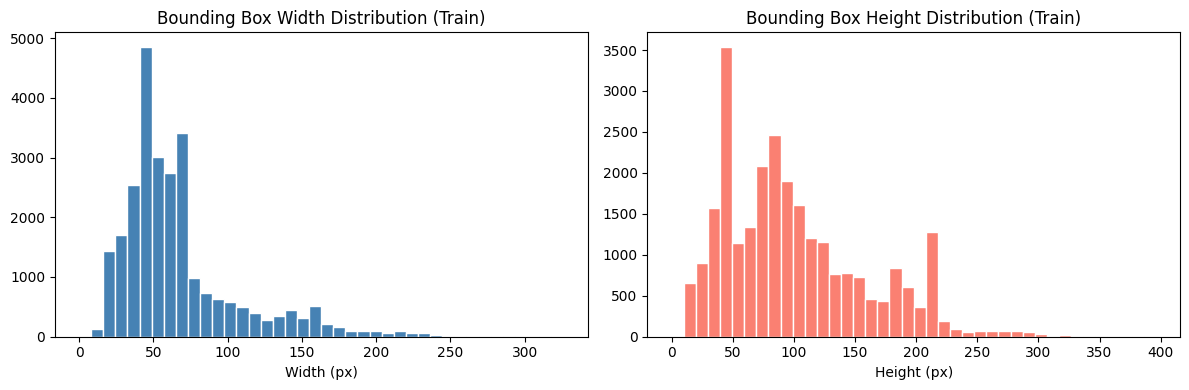

In [ ]:
# Optional bounding-box distribution plots.
all_widths, all_heights = [], []
for name in train_sequences:
    _, bboxes = load_sequence_with_gt(DATA_ROOT / name)
    all_widths.extend(bboxes[:, 2].tolist())
    all_heights.extend(bboxes[:, 3].tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_widths, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Bounding Box Width Distribution (Train)")
axes[0].set_xlabel("Width (px)")
axes[1].hist(all_heights, bins=40, color="salmon", edgecolor="white")
axes[1].set_title("Bounding Box Height Distribution (Train)")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "bbox_distribution.png", dpi=100, bbox_inches="tight")
plt.show()


## (Optional) Target Motion Visualization

For one selected sequence, plot the target center coordinates over time.

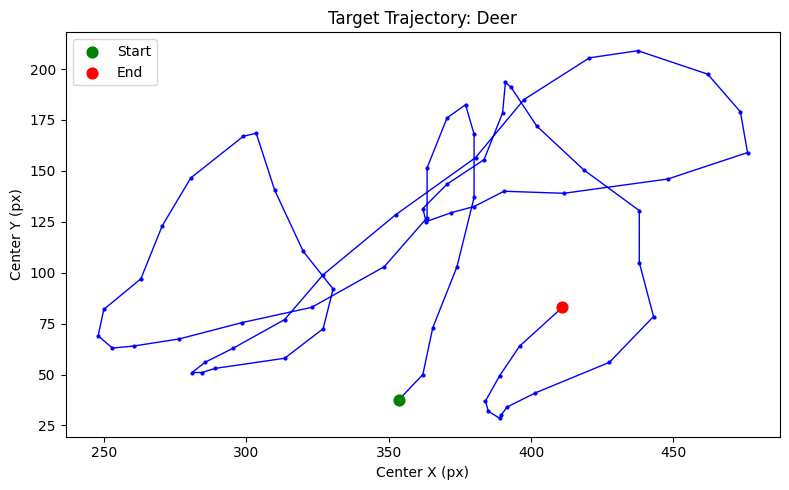

In [ ]:
# Optional trajectory visualization.
if train_sequences:
    seq_name = train_sequences[0]
    _, bboxes = load_sequence_with_gt(DATA_ROOT / seq_name)
    cx = bboxes[:, 0] + bboxes[:, 2] / 2
    cy = bboxes[:, 1] + bboxes[:, 3] / 2
    plt.figure(figsize=(8, 5))
    plt.plot(cx, cy, marker="o", markersize=2, linewidth=1, color="blue")
    plt.scatter([cx[0]], [cy[0]], color="green", s=60, zorder=5, label="Start")
    plt.scatter([cx[-1]], [cy[-1]], color="red", s=60, zorder=5, label="End")
    plt.title(f"Target Trajectory: {seq_name}")
    plt.xlabel("Center X (px)")
    plt.ylabel("Center Y (px)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"trajectory_{seq_name}.png", dpi=100, bbox_inches="tight")
    plt.show()


# PART 2 — Search-Region Sample Generation

In single-object tracking, the target is initialized in the first frame. For later frames, the tracker searches around the previous target location.

In this assignment, you will train a model that receives a local search crop and predicts the target box inside that crop.

For a pair of consecutive frames:

```text
Frame t-1 bbox -> used to define the search region in frame t
Frame t bbox   -> target label inside the search region
```

## 2.1 Crop Metadata

`CropInfo` stores the information needed to convert between:

- full-frame coordinates,
- crop-local normalized coordinates.

In [ ]:
@dataclass
class CropInfo:
    """
    Metadata for mapping between crop coordinates and full-frame coordinates.

    x1, y1:
        Top-left location of the crop in the original image coordinate system.
        These may be negative if padding is used.

    crop_size:
        Side length of the square crop in original image pixels.

    output_size:
        Side length after resizing the crop for the CNN.
    """
    x1: float
    y1: float
    crop_size: float
    output_size: int

## 2.2 Bounding-Box Helper Functions

Implement simple helper functions for bounding-box center computation and clipping predictions to image boundaries.

In [ ]:
def bbox_center(bbox: np.ndarray) -> Tuple[float, float]:
    """Compute the center of a bbox in (x, y, w, h) format."""
    return float(bbox[0] + bbox[2] / 2.0), float(bbox[1] + bbox[3] / 2.0)


def clip_bbox_to_image(bbox: np.ndarray, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Clip a bbox to image boundaries and keep width/height positive."""
    h_img, w_img = image_shape[:2]
    x, y, w, h = float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])
    x2 = x + w
    y2 = y + h
    x  = max(0.0, min(x, w_img - 1))
    y  = max(0.0, min(y, h_img - 1))
    x2 = max(0.0, min(x2, float(w_img)))
    y2 = max(0.0, min(y2, float(h_img)))
    return np.array([x, y, max(1.0, x2 - x), max(1.0, y2 - y)], dtype=np.float32)


## 2.3 Search-Region Crop

Use a square search region centered around the previous bounding box.

The recommended crop size is:

```text
crop_size = scale × max(previous_width, previous_height)
```

A reasonable default value is `scale = 2.5`.

If the crop goes outside the image, handle the boundary carefully. You may use padding or clipping, but your coordinate conversion must remain correct.

In [ ]:
def crop_search_region(
    image: np.ndarray,
    previous_bbox: np.ndarray,
    scale: float = 2.5,
    output_size: int = IMAGE_SIZE,
    pad_value: Tuple[int, int, int] = (128, 128, 128),
) -> Tuple[np.ndarray, CropInfo]:
    """
    Crop a square search region around the previous bounding box.

    Boundary handling: pad the image with pad_value so that the crop
    is always a full square — this keeps coordinate conversions simple.

    Returns:
        crop_resized: RGB crop resized to output_size x output_size
        crop_info: metadata for coordinate conversion
    """
    h_img, w_img = image.shape[:2]
    cx, cy = bbox_center(previous_bbox)
    crop_size = scale * max(float(previous_bbox[2]), float(previous_bbox[3]))
    crop_size = max(crop_size, 64.0)  # çok küçük bbox'larda crop küçülmesin

    # Top-left of the crop in original image coords (may be negative)
    x1 = cx - crop_size / 2.0
    y1 = cy - crop_size / 2.0
    x2 = x1 + crop_size
    y2 = y1 + crop_size

    # Padding amounts needed
    pad_left   = max(0, int(math.ceil(-x1)))
    pad_top    = max(0, int(math.ceil(-y1)))
    pad_right  = max(0, int(math.ceil(x2 - w_img)))
    pad_bottom = max(0, int(math.ceil(y2 - h_img)))

    # Pad image
    padded = cv2.copyMakeBorder(
        image, pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT, value=pad_value
    )

    # Crop coords in padded image
    px1 = int(round(x1 + pad_left))
    py1 = int(round(y1 + pad_top))
    px2 = px1 + int(round(crop_size))
    py2 = py1 + int(round(crop_size))

    # Safety clamp
    px1 = max(0, px1)
    py1 = max(0, py1)
    px2 = min(padded.shape[1], px2)
    py2 = min(padded.shape[0], py2)

    crop = padded[py1:py2, px1:px2]
    if crop.size == 0:
        crop = np.full((int(crop_size), int(crop_size), 3), pad_value, dtype=np.uint8)

    crop_resized = cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_LINEAR)

    # CropInfo stores top-left in ORIGINAL image coords
    crop_info = CropInfo(
        x1=x1,
        y1=y1,
        crop_size=float(crop_size),
        output_size=output_size,
    )
    return crop_resized, crop_info


## 2.4 Coordinate Conversion

The model predicts boxes inside the crop, but the final tracking output must be in full-frame coordinates.

You need two conversions:

1. Full-frame bbox → crop-local normalized bbox  
2. Crop-local normalized bbox → full-frame bbox

In [ ]:
def bbox_to_crop_coordinates(bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a full-frame bbox into normalized crop coordinates.

    Steps:
      1. Shift bbox by crop top-left (x1, y1).
      2. Normalize by crop_size.

    Returns:
        normalized_bbox: (x, y, w, h), usually in [0, 1]
    """
    x_norm = (bbox[0] - crop_info.x1) / crop_info.crop_size
    y_norm = (bbox[1] - crop_info.y1) / crop_info.crop_size
    w_norm = bbox[2] / crop_info.crop_size
    h_norm = bbox[3] / crop_info.crop_size
    return np.array([x_norm, y_norm, w_norm, h_norm], dtype=np.float32)


def crop_to_frame_coordinates(normalized_bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a normalized crop-local bbox back to full-frame coordinates.
    """
    x = normalized_bbox[0] * crop_info.crop_size + crop_info.x1
    y = normalized_bbox[1] * crop_info.crop_size + crop_info.y1
    w = normalized_bbox[2] * crop_info.crop_size
    h = normalized_bbox[3] * crop_info.crop_size
    return np.array([x, y, w, h], dtype=np.float32)


## 2.5 Search-Region Visualization

Visualize several generated search-region samples.

For each sample, draw the current target box inside the search crop.

This is one of the most important sanity checks in the assignment.

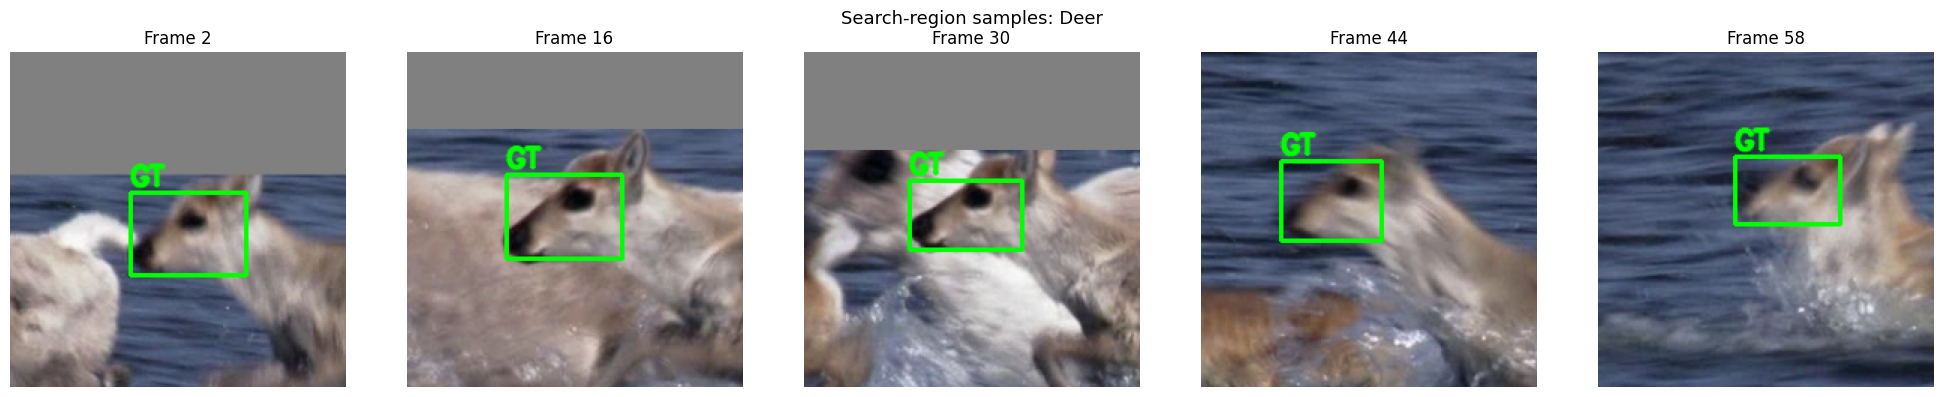

In [ ]:
# Visualize generated search-region samples.
# For each sample: show the search crop with the current GT box drawn inside.
if train_sequences:
    seq_name = train_sequences[0]
    seq_path = DATA_ROOT / seq_name
    frame_paths, bboxes = load_sequence_with_gt(seq_path)

    n_show = min(5, len(frame_paths) - 1)
    step   = max(1, (len(frame_paths) - 1) // n_show)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f"Search-region samples: {seq_name}", fontsize=13)

    for k, ax in enumerate(axes):
        t = k * step + 1
        img_t   = read_image_rgb(frame_paths[t])
        prev_bb = bboxes[t - 1]
        curr_bb = bboxes[t]

        crop, crop_info = crop_search_region(img_t, prev_bb, scale=SEARCH_SCALE)
        norm_bb = bbox_to_crop_coordinates(curr_bb, crop_info)

        # Draw in resized (224x224) crop pixel space
        px = norm_bb[0] * IMAGE_SIZE
        py = norm_bb[1] * IMAGE_SIZE
        pw = norm_bb[2] * IMAGE_SIZE
        ph = norm_bb[3] * IMAGE_SIZE
        vis = draw_bbox(crop, np.array([px, py, pw, ph]), color=(0, 255, 0), label="GT")

        ax.imshow(vis)
        ax.set_title(f"Frame {t + 1}")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "search_region_samples.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("Load splits first.")


# PART 3 — CNN-Based Bounding-Box Regression Model

In this part, you will train a CNN to predict the target bounding box inside a search crop.

The model input is:

```text
224 × 224 RGB search crop
```

The model output is:

```text
x, y, width, height
```

The output must be crop-local and normalized to `[0, 1]`.

Do not train the model with full-frame coordinates.

## 3.1 Model Architecture Overview

Recommended architecture:

```text
Search Region Crop
        ↓
Preprocessing
        ↓
CNN Backbone
        ↓
Regression Head
        ↓
Normalized Bounding Box [x, y, w, h]
        ↓
Convert to full-frame coordinates during tracking
```

You may use an ImageNet-pretrained ResNet18 backbone. Replace its final classification layer with a regression layer that outputs four values.

## 3.2 PyTorch Dataset

Implement a PyTorch dataset that generates search-region samples from training sequences.

Each sample should contain:

```text
input: search crop from current frame
target: current target bbox in crop-local normalized coordinates
```

Use validation sequences similarly for crop-level validation.

In [ ]:
class SearchRegionDataset(Dataset):
    """
    Dataset that generates search-region samples from full-GT sequences.

    Each sample:
        input: current frame search crop around previous GT bbox
        target: current GT bbox in normalized crop coordinates
    """

    def __init__(
        self,
        data_root: Path,
        sequence_names: List[str],
        image_size: int = IMAGE_SIZE,
        search_scale: float = SEARCH_SCALE,
        augment: bool = False,
    ):
        self.data_root = Path(data_root)
        self.sequence_names = sequence_names
        self.image_size = image_size
        self.search_scale = search_scale
        self.augment = augment

        self.samples = []  # list of (frame_path, prev_bbox, curr_bbox)

        for seq_name in sequence_names:
            seq_path = self.data_root / seq_name
            try:
                frame_paths, bboxes = load_sequence_with_gt(seq_path)
            except Exception as e:
                print(f"  Skipping {seq_name}: {e}")
                continue
            for t in range(1, len(frame_paths)):
                self.samples.append({
                    "frame_path": frame_paths[t],
                    "prev_bbox":  bboxes[t - 1].copy(),
                    "curr_bbox":  bboxes[t].copy(),
                    "seq_name":   seq_name,
                    "frame_idx":  t,
                })

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = read_image_rgb(sample["frame_path"])

        crop, crop_info = crop_search_region(
            img, sample["prev_bbox"],
            scale=self.search_scale,
            output_size=self.image_size,
        )

        target_norm = bbox_to_crop_coordinates(sample["curr_bbox"], crop_info)
        # Clamp to [0, 1] to avoid numerical issues at boundaries
        target_norm = np.clip(target_norm, 0.0, 1.0).astype(np.float32)

        crop_tensor = self.transform(crop)
        target_tensor = torch.from_numpy(target_norm)

        return crop_tensor, target_tensor


## 3.3 DataLoaders

Create train and validation DataLoaders.

Training samples should come only from the training split. Validation samples should come only from the validation split.

In [ ]:
def create_dataloaders(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    batch_size: int = BATCH_SIZE,
    image_size: int = IMAGE_SIZE,
    search_scale: float = SEARCH_SCALE,
):
    """Create train and validation dataloaders."""
    train_dataset = SearchRegionDataset(
        data_root, train_sequences,
        image_size=image_size, search_scale=search_scale, augment=True
    )
    val_dataset = SearchRegionDataset(
        data_root, val_sequences,
        image_size=image_size, search_scale=search_scale, augment=False
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
    return train_loader, val_loader, train_dataset, val_dataset


# Create dataloaders after loading splits
train_loader, val_loader, train_dataset, val_dataset = create_dataloaders(
    DATA_ROOT, train_sequences, val_sequences
)


Train samples: 26548, Val samples: 5041


## 3.4 Model Definition

Define your CNN-based bounding-box regressor.

Recommended design:
- pretrained ResNet18 backbone,
- final regression layer with 4 outputs,
- output activation to keep predictions in `[0, 1]`.

In [ ]:
class TrackingRegressor(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()

        # Load ResNet18 with optional pretrained weights
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = torchvision.models.resnet18(weights=weights)

        # Remove the final classification layer; keep everything up to avgpool
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # output: (B, 512, 1, 1)

        # Regression head: 512 -> 4 (x, y, w, h) normalized to [0,1]
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 4),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat = self.features(x)   # (B, 512, 1, 1)
        bbox = self.regressor(feat)
        return bbox


def create_model() -> nn.Module:
    model = TrackingRegressor(pretrained=True).to(DEVICE)
    return model


# Initialize model
model = create_model()
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


TrackingRegressor(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

## 3.5 IoU for Crop-Level Validation

Implement IoU calculation for boxes in `(x, y, w, h)` format.

This function will be used both for crop-level validation and sequence-level evaluation.

In [ ]:
def compute_iou_np(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute IoU between two boxes in (x, y, w, h) format."""
    ax1, ay1 = box_a[0], box_a[1]
    ax2, ay2 = ax1 + box_a[2], ay1 + box_a[3]

    bx1, by1 = box_b[0], box_b[1]
    bx2, by2 = bx1 + box_b[2], by1 + box_b[3]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = box_a[2] * box_a[3]
    area_b = box_b[2] * box_b[3]
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0
    return float(inter_area / union_area)


def mean_iou_batch(preds: torch.Tensor, targets: torch.Tensor) -> float:
    """Compute mean IoU for a batch of predicted and target boxes."""
    preds_np   = preds.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()
    ious = [compute_iou_np(preds_np[i], targets_np[i]) for i in range(len(preds_np))]
    return float(np.mean(ious)) if ious else 0.0


## 3.6 Training and Validation Loops

Use a regression loss such as Smooth L1 loss.

During training, update model parameters.  
During validation, do not update model parameters.

Record:
- training loss,
- validation loss,
- validation crop-level mean IoU.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train model for one epoch."""
    model.train()
    total_loss = 0.0
    for crops, targets in loader:
        crops   = crops.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(crops)
        loss  = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(crops)

    return total_loss / max(len(loader.dataset), 1)


@torch.no_grad()
def validate_model(model, loader, criterion, device):
    """
    Validate model.

    Returns:
        dictionary with validation loss and validation crop-level mean IoU
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for crops, targets in loader:
        crops   = crops.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        preds = model(crops)
        loss  = criterion(preds, targets)
        total_loss += loss.item() * len(crops)

        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    val_loss = total_loss / max(len(loader.dataset), 1)
    val_iou  = mean_iou_batch(all_preds, all_targets)

    return {"val_loss": val_loss, "val_iou": val_iou}


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs: int = NUM_EPOCHS,
    lr: float = LEARNING_RATE,
    device: torch.device = DEVICE,
):
    """Full training loop."""
    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_iou": []}
    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_model(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["val_loss"])
        history["val_iou"].append(val_metrics["val_iou"])

        print(
            f"Epoch {epoch:3d}/{num_epochs} | "
            f"Train Loss: {train_loss:.5f} | "
            f"Val Loss: {val_metrics['val_loss']:.5f} | "
            f"Val IoU: {val_metrics['val_iou']:.4f}"
        )

        if val_metrics["val_loss"] < best_val_loss:
            best_val_loss = val_metrics["val_loss"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model with val_loss={best_val_loss:.5f}")

    return history


## 3.7 Train the Model

Train your model using the training split and monitor performance on the validation split.

Save the best model according to validation performance.

In [ ]:
# Train and save your model
checkpoint_dir = Path("checkpoint")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
)

# Save best model weights
checkpoint_path = checkpoint_dir / "best_model.pth"
torch.save(model.state_dict(), checkpoint_path)
print(f"Model saved to {checkpoint_path}")


Epoch   1/15 | Train Loss: 0.00094 | Val Loss: 0.00089 | Val IoU: 0.6660
Epoch   2/15 | Train Loss: 0.00041 | Val Loss: 0.00086 | Val IoU: 0.6621
Epoch   3/15 | Train Loss: 0.00032 | Val Loss: 0.00084 | Val IoU: 0.6842
Epoch   4/15 | Train Loss: 0.00026 | Val Loss: 0.00082 | Val IoU: 0.6837
Epoch   5/15 | Train Loss: 0.00023 | Val Loss: 0.00101 | Val IoU: 0.6544
Epoch   6/15 | Train Loss: 0.00020 | Val Loss: 0.00097 | Val IoU: 0.6441
Epoch   7/15 | Train Loss: 0.00019 | Val Loss: 0.00096 | Val IoU: 0.6657
Epoch   8/15 | Train Loss: 0.00017 | Val Loss: 0.00091 | Val IoU: 0.6627
Epoch   9/15 | Train Loss: 0.00016 | Val Loss: 0.00092 | Val IoU: 0.6756
Epoch  10/15 | Train Loss: 0.00015 | Val Loss: 0.00088 | Val IoU: 0.6711
Epoch  11/15 | Train Loss: 0.00015 | Val Loss: 0.00080 | Val IoU: 0.6869
Epoch  12/15 | Train Loss: 0.00014 | Val Loss: 0.00090 | Val IoU: 0.6823
Epoch  13/15 | Train Loss: 0.00013 | Val Loss: 0.00095 | Val IoU: 0.6712
Epoch  14/15 | Train Loss: 0.00012 | Val Loss: 0.00

## 3.8 Training Curves

Plot:
- training loss,
- validation loss,
- validation crop-level mean IoU.

Briefly comment on whether the model appears to learn.

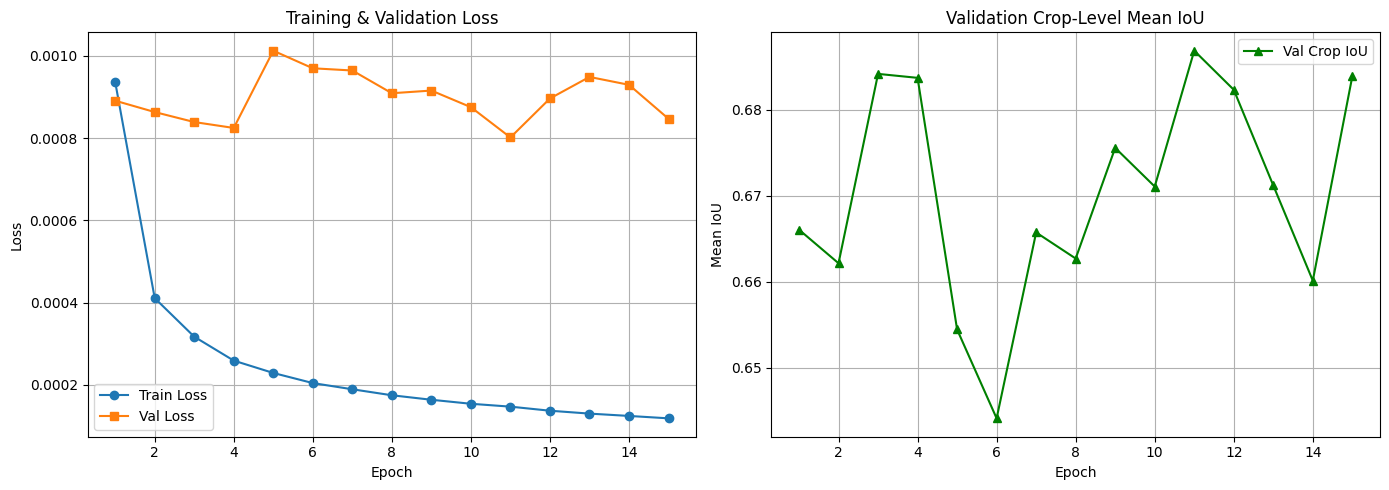

Best Val Loss: 0.00080
Best Val IoU : 0.6869


In [ ]:
# Plot training and validation loss curves + val crop IoU
epochs = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["val_iou"], label="Val Crop IoU", marker="^", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean IoU")
axes[1].set_title("Validation Crop-Level Mean IoU")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "training_curves.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Best Val Loss: {min(history['val_loss']):.5f}")
print(f"Best Val IoU : {max(history['val_iou']):.4f}")


## 3.9 Visualize Crop-Level Validation Predictions

Visualize at least five validation crop predictions.

Draw:
- ground-truth box,
- predicted box.

This helps check whether the model learned meaningful localization.

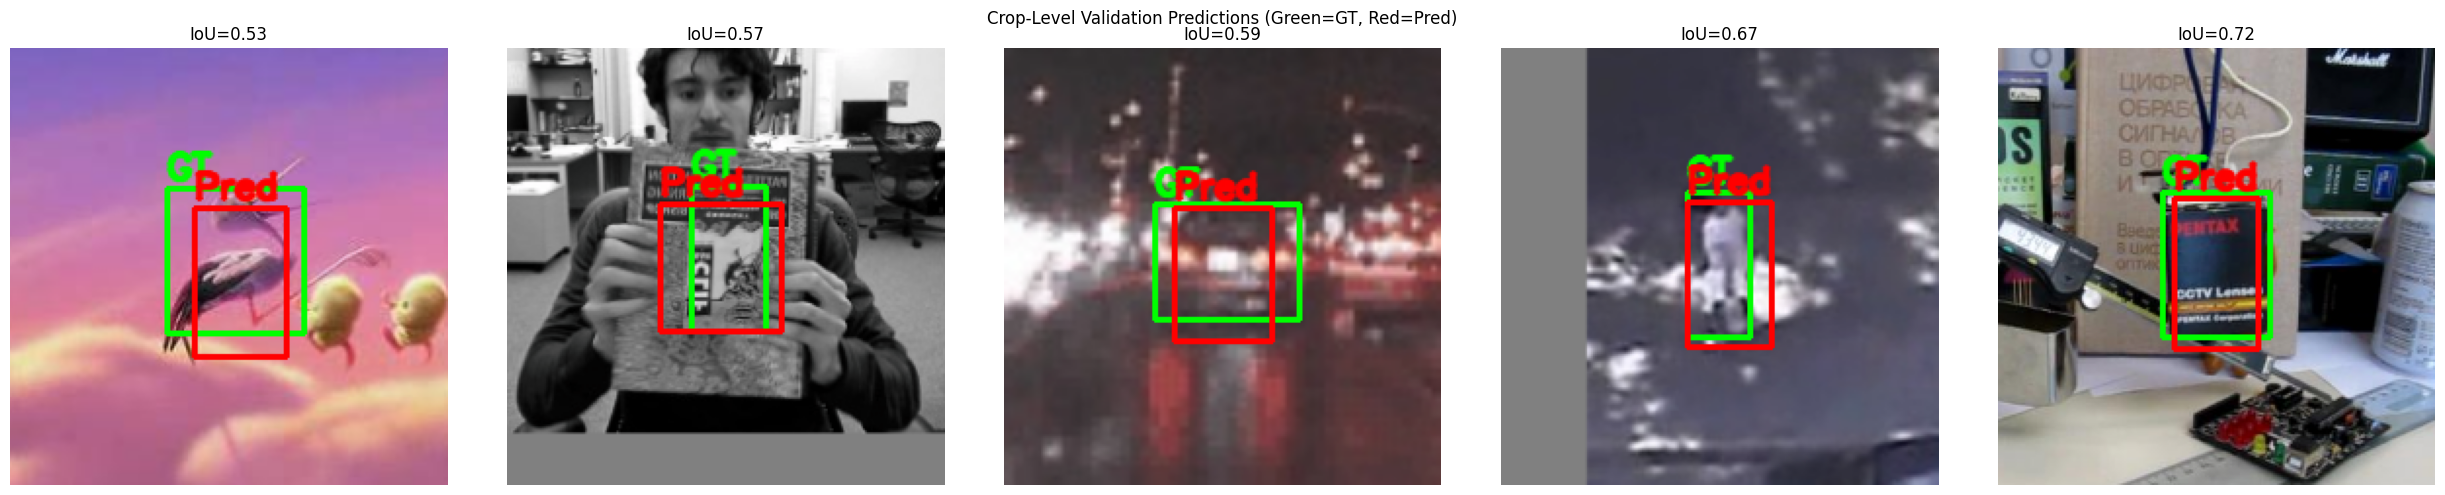

In [ ]:
def denormalize_tensor_image(tensor_img: torch.Tensor) -> np.ndarray:
    """Convert a normalized tensor image back to a uint8 RGB image for visualization."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = tensor_img.permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    img = img * std + mean
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img


@torch.no_grad()
def visualize_validation_predictions(model, dataset, num_samples: int = 5):
    """Visualize model predictions on validation crop samples."""
    model.eval()
    indices = np.linspace(0, len(dataset) - 1, num_samples, dtype=int)
    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    if num_samples == 1:
        axes = [axes]
    fig.suptitle("Crop-Level Validation Predictions (Green=GT, Red=Pred)", fontsize=12)

    for ax, idx in zip(axes, indices):
        crop_tensor, target_tensor = dataset[int(idx)]
        pred_tensor = model(crop_tensor.unsqueeze(0).to(DEVICE))[0].cpu()

        img = denormalize_tensor_image(crop_tensor)

        # Convert normalized coords -> 224x224 pixel coords
        gt_px   = target_tensor.numpy() * IMAGE_SIZE
        pred_px = pred_tensor.numpy()   * IMAGE_SIZE

        img = draw_bbox(img, gt_px,   color=(0, 255, 0), label="GT")
        img = draw_bbox(img, pred_px, color=(255, 0, 0), label="Pred")

        ax.imshow(img)
        iou = compute_iou_np(gt_px, pred_px)
        ax.set_title(f"IoU={iou:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "crop_val_predictions.png", dpi=100, bbox_inches="tight")
    plt.show()


# Visualize validation predictions
visualize_validation_predictions(model, val_dataset, num_samples=5)


# PART 4 — Single-Object Tracking on Validation and Test Sequences

After training the model, use it as a tracker.

For validation sequences:
- use the first line of `groundtruth_rect.txt` as initialization,
- predict all later frames,
- evaluate after tracking.

For test sequences:
- use `init_rect.txt` as initialization,
- predict all later frames,
- save CSV files,
- do not evaluate locally.

## 4.1 Evaluation-Time Preprocessing

Use the same preprocessing during tracking that you used during training.

Do not apply random augmentation during validation or test tracking.

In [ ]:
eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 4.2 Predict a Box Inside One Crop

This helper runs the model on one search crop and returns a normalized crop-local bounding box.

In [ ]:
@torch.no_grad()
def predict_bbox_in_crop(model, crop_rgb: np.ndarray, device: torch.device = DEVICE) -> np.ndarray:
    """Run the model on a crop and return normalized bbox prediction."""
    model.eval()
    crop_tensor = eval_transform(crop_rgb).unsqueeze(0).to(device)
    pred = model(crop_tensor)[0].cpu().numpy()
    return pred.astype(np.float32)


## 4.3 Tracking Loop

Implement the full single-object tracking loop.

The function should receive only:

```text
model
frame paths
initial bbox
```

It must not receive the full ground-truth array.

In [ ]:
@torch.no_grad()
def track_sequence(
    model, frame_paths, initial_bbox,
    device=DEVICE, scale=SEARCH_SCALE, image_size=IMAGE_SIZE,
):
    model.eval()
    predictions = [initial_bbox.copy()]
    prev_bbox   = initial_bbox.copy()
    # İlk frame'den boyutu kilitle
    init_w = initial_bbox[2]
    init_h = initial_bbox[3]

    for t in range(1, len(frame_paths)):
        img = read_image_rgb(frame_paths[t])

        crop, crop_info = crop_search_region(
            img, prev_bbox, scale=scale, output_size=image_size
        )
        norm_pred  = predict_bbox_in_crop(model, crop, device=device)
        frame_bbox = crop_to_frame_coordinates(norm_pred, crop_info)
        frame_bbox = clip_bbox_to_image(frame_bbox, img.shape)

        # Boyutu ilk frame'e göre sınırla (tüm resmi kaplamasın)
        max_w = init_w * 3.0
        max_h = init_h * 3.0
        frame_bbox[2] = float(np.clip(frame_bbox[2], init_w * 0.3, max_w))
        frame_bbox[3] = float(np.clip(frame_bbox[3], init_h * 0.3, max_h))

        # Sadece konum smooth, boyutu daha sert sabitle
        alpha = 0.7
        smoothed = prev_bbox.copy()
        smoothed[0] = alpha * frame_bbox[0] + (1 - alpha) * prev_bbox[0]
        smoothed[1] = alpha * frame_bbox[1] + (1 - alpha) * prev_bbox[1]
        smoothed[2] = 0.2 * frame_bbox[2] + 0.8 * prev_bbox[2]  # boyut çok yavaş değişsin
        smoothed[3] = 0.2 * frame_bbox[3] + 0.8 * prev_bbox[3]

        predictions.append(smoothed.copy())
        prev_bbox = smoothed.copy()

    return np.stack(predictions, axis=0)

## 4.4 Save Prediction CSV Files

Save predictions in the required format.

The saved coordinates must be full-frame pixel coordinates.

In [ ]:
def save_predictions_csv(predictions: np.ndarray, output_path: Path):
    """
    Save predictions in CSV format:

    frame,x,y,w,h
    1,...
    2,...

    Coordinates must be full-frame pixel coordinates, not normalized crop coordinates.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame", "x", "y", "w", "h"])
        for i, bbox in enumerate(predictions, start=1):
            writer.writerow([i, round(float(bbox[0]), 4), round(float(bbox[1]), 4),
                             round(float(bbox[2]), 4), round(float(bbox[3]), 4)])


## 4.5 Run Tracking on Validation Sequences

Use the first validation ground-truth box for initialization.

Save validation predictions under:

```text
outputs/validation/
```

In [ ]:
def run_tracking_on_validation_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track validation sequences and save CSV prediction files."""
    val_output_dir = output_root / "validation"
    val_output_dir.mkdir(parents=True, exist_ok=True)
    predictions_by_sequence = {}

    for seq_name in sequence_names:
        seq_path = data_root / seq_name
        frame_paths, bboxes = load_sequence_with_gt(seq_path)
        initial_bbox = bboxes[0]

        preds = track_sequence(model, frame_paths, initial_bbox, device=device, scale=scale)
        predictions_by_sequence[seq_name] = preds

        csv_path = val_output_dir / f"{seq_name}_predictions.csv"
        save_predictions_csv(preds, csv_path)
        print(f"  [{seq_name}] {len(preds)} frames -> {csv_path}")

    return predictions_by_sequence


## 4.6 Run Tracking on Test Sequences

Use `init_rect.txt` for initialization.

Save test predictions under:

```text
outputs/test/
```

These files will be submitted for evaluation.

In [ ]:
def run_tracking_on_test_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track test sequences and save CSV prediction files."""
    test_output_dir = output_root / "test"
    test_output_dir.mkdir(parents=True, exist_ok=True)
    predictions_by_sequence = {}

    for seq_name in sequence_names:
        seq_path = data_root / seq_name
        frame_paths, initial_bbox = load_test_sequence(seq_path)

        preds = track_sequence(model, frame_paths, initial_bbox, device=device, scale=scale)
        predictions_by_sequence[seq_name] = preds

        csv_path = test_output_dir / f"{seq_name}_predictions.csv"
        save_predictions_csv(preds, csv_path)
        print(f"  [{seq_name}] {len(preds)} frames -> {csv_path}")

    return predictions_by_sequence


## 4.7 Execute Tracking

Run tracking on validation and test sequences.

Make sure the generated test CSV files are complete and correctly formatted.

In [ ]:
# Run tracking on validation sequences
print("=== Tracking Validation Sequences ===")
val_predictions = run_tracking_on_validation_sequences(
    model, DATA_ROOT, val_sequences, OUTPUT_ROOT, device=DEVICE
)

# Run tracking on hidden test sequences and save CSV files
print("\n=== Tracking Test Sequences ===")
test_predictions = run_tracking_on_test_sequences(
    model, DATA_ROOT, test_sequences, OUTPUT_ROOT, device=DEVICE
)


=== Tracking Validation Sequences ===
  [Bird2] 99 frames -> outputs/validation/Bird2_predictions.csv
  [Fish] 476 frames -> outputs/validation/Fish_predictions.csv
  [Human4] 667 frames -> outputs/validation/Human4_predictions.csv
  [ClifBar] 472 frames -> outputs/validation/ClifBar_predictions.csv
  [Bolt] 350 frames -> outputs/validation/Bolt_predictions.csv
  [MountainBike] 228 frames -> outputs/validation/MountainBike_predictions.csv
  [CarDark] 393 frames -> outputs/validation/CarDark_predictions.csv
  [Man] 134 frames -> outputs/validation/Man_predictions.csv
  [Basketball] 725 frames -> outputs/validation/Basketball_predictions.csv
  [Crowds] 347 frames -> outputs/validation/Crowds_predictions.csv
  [Box] 1161 frames -> outputs/validation/Box_predictions.csv

=== Tracking Test Sequences ===
  [TestSeq1] 1345 frames -> outputs/test/TestSeq1_predictions.csv
  [TestSeq2] 354 frames -> outputs/test/TestSeq2_predictions.csv
  [TestSeq3] 812 frames -> outputs/test/TestSeq3_prediction

# Required Test Output Format

For each test sequence, save one CSV file:

```text
outputs/test/<sequence_name>_predictions.csv
```

Each CSV file must contain:

```text
frame,x,y,w,h
```

Rules:

1. Number of rows must equal the number of frames.
2. Frame numbering must start from 1.
3. The first-frame prediction should be the initialization box from `init_rect.txt`.
4. Coordinates must be full-frame pixel coordinates.
5. Do not save normalized crop coordinates.
6. Bounding boxes must be in `(x, y, width, height)` format.

# PART 5 — Validation Evaluation and Analysis

Evaluate your tracker on validation sequences using the provided validation ground truth.

Do not evaluate test sequences. Test ground truth is hidden and will be evaluated by the instructors.

Required validation metrics:

1. Mean IoU  
2. Success Rate @ IoU ≥ 0.5  
3. Average Center Error  
4. Failure Count, where failure means IoU < 0.1

## 5.1 Metric Functions

Implement IoU, center error, and sequence-level evaluation.

In [ ]:
def compute_iou(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute intersection-over-union between two boxes in (x, y, w, h) format."""
    return compute_iou_np(box_a, box_b)


def compute_center_error(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Compute Euclidean distance between the centers of two boxes."""
    cx_a, cy_a = box_a[0] + box_a[2] / 2.0, box_a[1] + box_a[3] / 2.0
    cx_b, cy_b = box_b[0] + box_b[2] / 2.0, box_b[1] + box_b[3] / 2.0
    return float(math.sqrt((cx_a - cx_b) ** 2 + (cy_a - cy_b) ** 2))


def evaluate_sequence(
    predictions: np.ndarray,
    ground_truth: np.ndarray,
    success_iou_threshold: float = 0.5,
    failure_iou_threshold: float = 0.1,
) -> Dict[str, float]:
    """
    Evaluate one validation tracking sequence.

    Returns:
        metrics dictionary with:
        - mean_iou
        - success_rate_0.5
        - avg_center_error
        - failure_count
        - num_frames
    """
    assert len(predictions) == len(ground_truth), "Prediction / GT length mismatch"
    n = len(predictions)
    ious, center_errors = [], []
    failure_count = 0
    success_count = 0

    for pred, gt in zip(predictions, ground_truth):
        iou = compute_iou(pred, gt)
        ce  = compute_center_error(pred, gt)
        ious.append(iou)
        center_errors.append(ce)
        if iou < failure_iou_threshold:
            failure_count += 1
        if iou >= success_iou_threshold:
            success_count += 1

    return {
        "mean_iou":        float(np.mean(ious)),
        "success_rate_0.5": float(success_count / n),
        "avg_center_error": float(np.mean(center_errors)),
        "failure_count":    int(failure_count),
        "num_frames":       int(n),
    }


## 5.2 Evaluate All Validation Sequences

Create a result table with one row per validation sequence and one final average row.

In [ ]:
def evaluate_validation_sequences(
    predictions_by_sequence: Dict[str, np.ndarray],
    data_root: Path,
) -> pd.DataFrame:
    """Evaluate all validation sequences and return a result table."""
    rows = []
    for seq_name, preds in predictions_by_sequence.items():
        _, gt_bboxes = load_sequence_with_gt(data_root / seq_name)
        metrics = evaluate_sequence(preds, gt_bboxes)
        rows.append({
            "Sequence":           seq_name,
            "Mean IoU":           round(metrics["mean_iou"], 4),
            "Success Rate @0.5":  round(metrics["success_rate_0.5"], 4),
            "Avg. Center Error":  round(metrics["avg_center_error"], 2),
            "Failure Count":      metrics["failure_count"],
            "Num Frames":         metrics["num_frames"],
        })

    df = pd.DataFrame(rows)
    # Average row
    avg_row = {
        "Sequence":           "Average",
        "Mean IoU":           round(df["Mean IoU"].mean(), 4),
        "Success Rate @0.5":  round(df["Success Rate @0.5"].mean(), 4),
        "Avg. Center Error":  round(df["Avg. Center Error"].mean(), 2),
        "Failure Count":      int(df["Failure Count"].sum()),
        "Num Frames":         int(df["Num Frames"].sum()),
    }
    df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
    return df


# Evaluate validation predictions
results_df = evaluate_validation_sequences(val_predictions, DATA_ROOT)
print(results_df.to_string(index=False))


    Sequence  Mean IoU  Success Rate @0.5  Avg. Center Error  Failure Count  Num Frames
       Bird2    0.2389             0.0303              84.84             38          99
        Fish    0.0273             0.0126             176.22            440         476
      Human4    0.1327             0.1469             164.46            491         667
     ClifBar    0.0412             0.0042              86.30            386         472
        Bolt    0.1007             0.0457             104.33            215         350
MountainBike    0.0192             0.0132             265.95            216         228
     CarDark    0.4344             0.2901               6.13             31         393
         Man    0.5037             0.6119              10.12              0         134
  Basketball    0.0197             0.0055             231.13            677         725
      Crowds    0.0266             0.0231             423.60            327         347
         Box    0.1241          

## 5.3 Visualize Validation Tracking Results

Visualize tracking results for at least three validation sequences.

For each selected sequence, show:
- an early frame,
- a middle frame,
- a late frame.

Draw both the ground-truth and predicted bounding boxes.

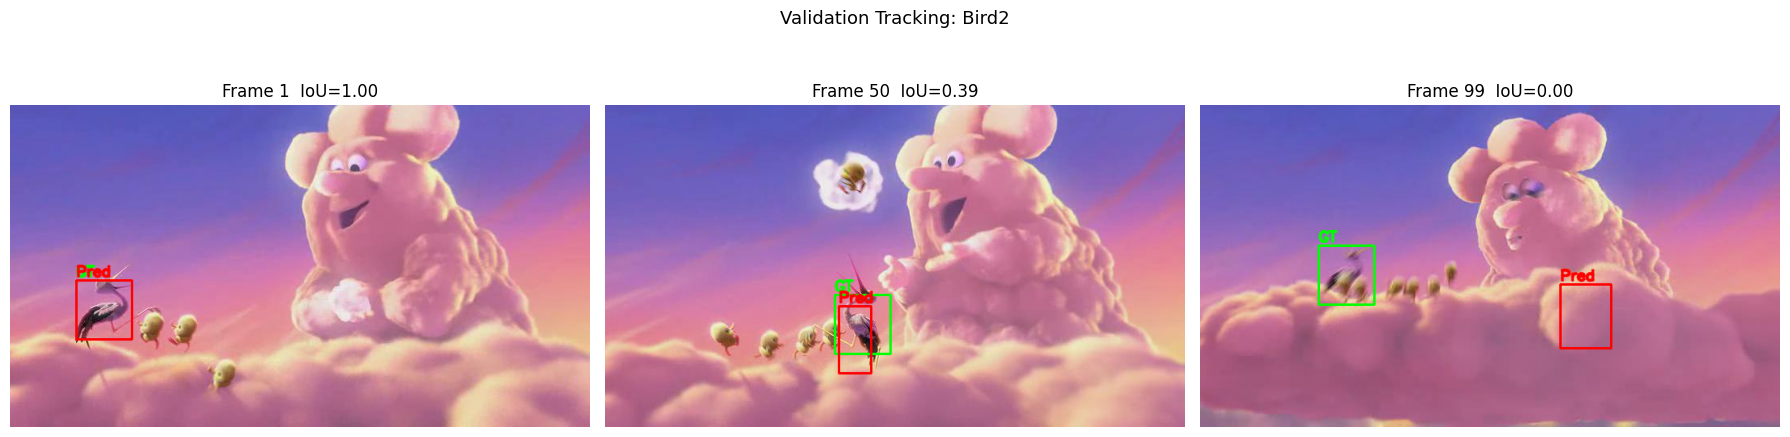

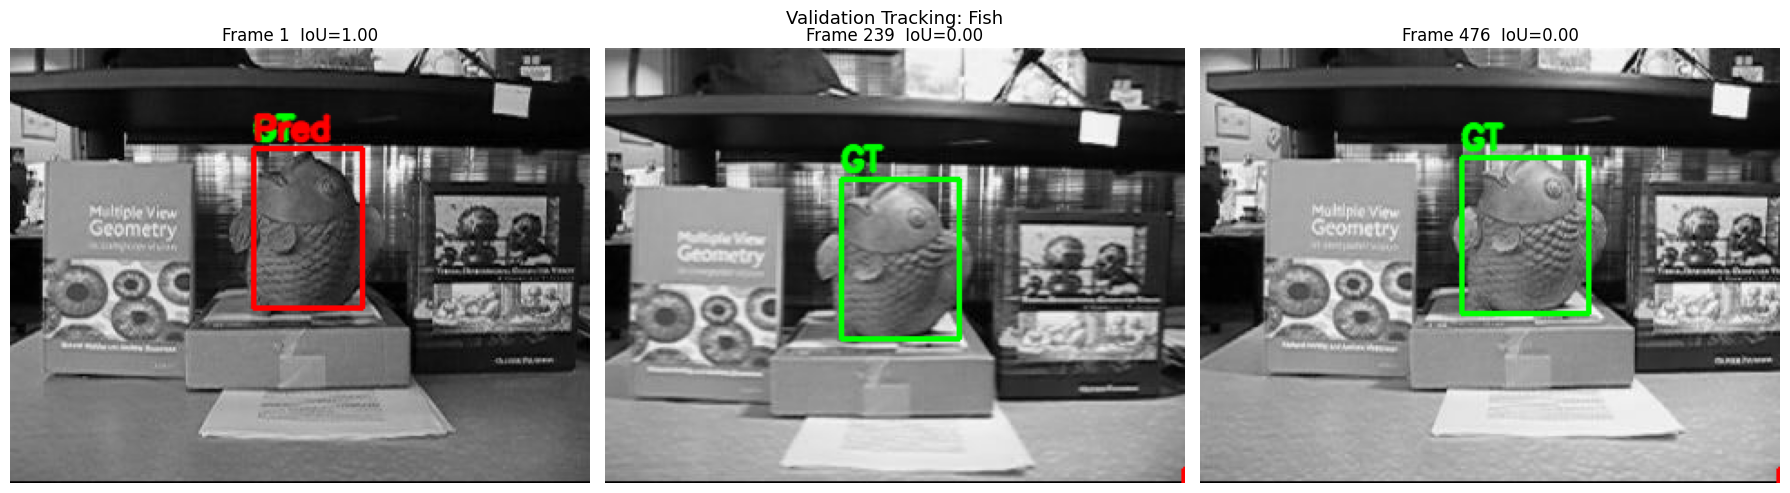

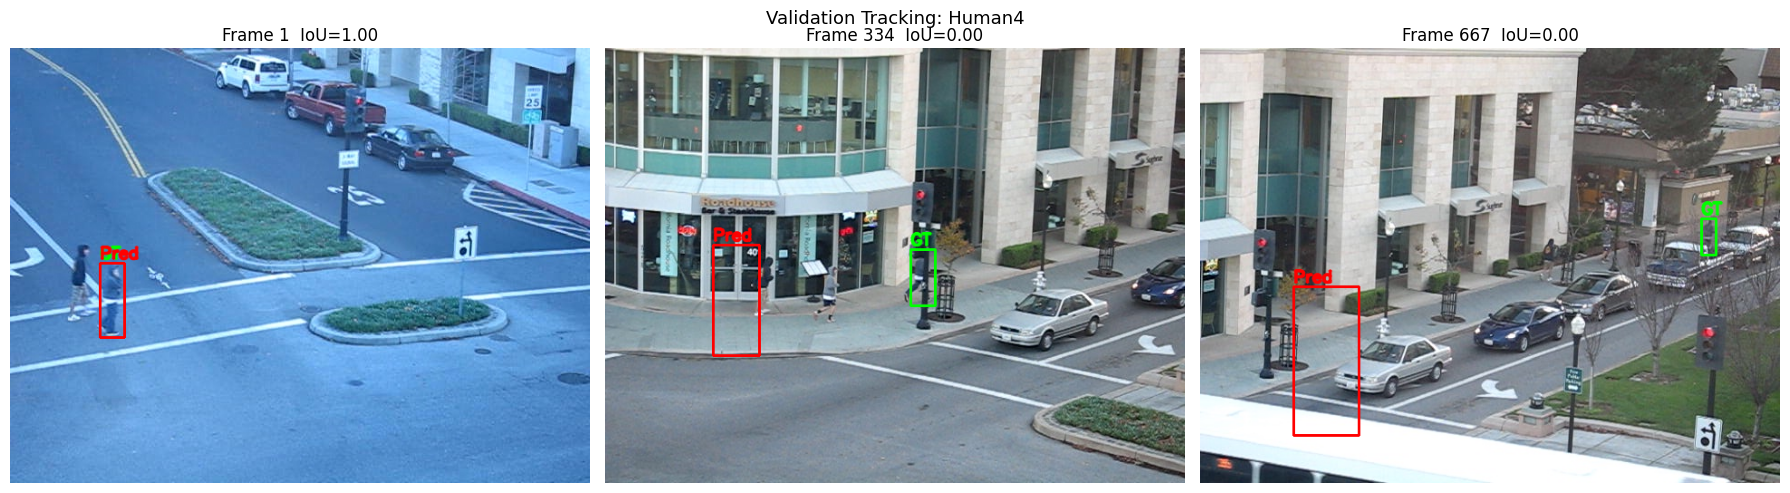

In [ ]:
def visualize_validation_tracking_result(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    frame_indices: Optional[List[int]] = None,
):
    """Visualize tracking predictions and ground truth for selected validation frames."""
    frame_paths, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    n = len(frame_paths)

    if frame_indices is None:
        # Early, middle, late
        frame_indices = [0, n // 2, n - 1]

    fig, axes = plt.subplots(1, len(frame_indices), figsize=(6 * len(frame_indices), 5))
    if len(frame_indices) == 1:
        axes = [axes]
    fig.suptitle(f"Validation Tracking: {sequence_name}", fontsize=13)

    for ax, idx in zip(axes, frame_indices):
        img = read_image_rgb(frame_paths[idx])
        img = draw_bbox(img, gt_bboxes[idx],  color=(0, 255, 0), label="GT")
        img = draw_bbox(img, predictions[idx], color=(255, 0, 0), label="Pred")
        iou = compute_iou(predictions[idx], gt_bboxes[idx])
        ax.imshow(img)
        ax.set_title(f"Frame {idx + 1}  IoU={iou:.2f}")
        ax.axis("off")

    plt.tight_layout()
    save_path = OUTPUT_ROOT / f"tracking_val_{sequence_name}.png"
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()


# Visualize tracking results for at least three validation sequences
for seq_name in list(val_predictions.keys())[:3]:
    visualize_validation_tracking_result(seq_name, val_predictions[seq_name], DATA_ROOT)


## 5.4 Failure-Case Analysis

Find frames where the tracker performs poorly.

At minimum, show:
- three successful frames,
- three failure cases.

For each failure case, explain what went wrong.

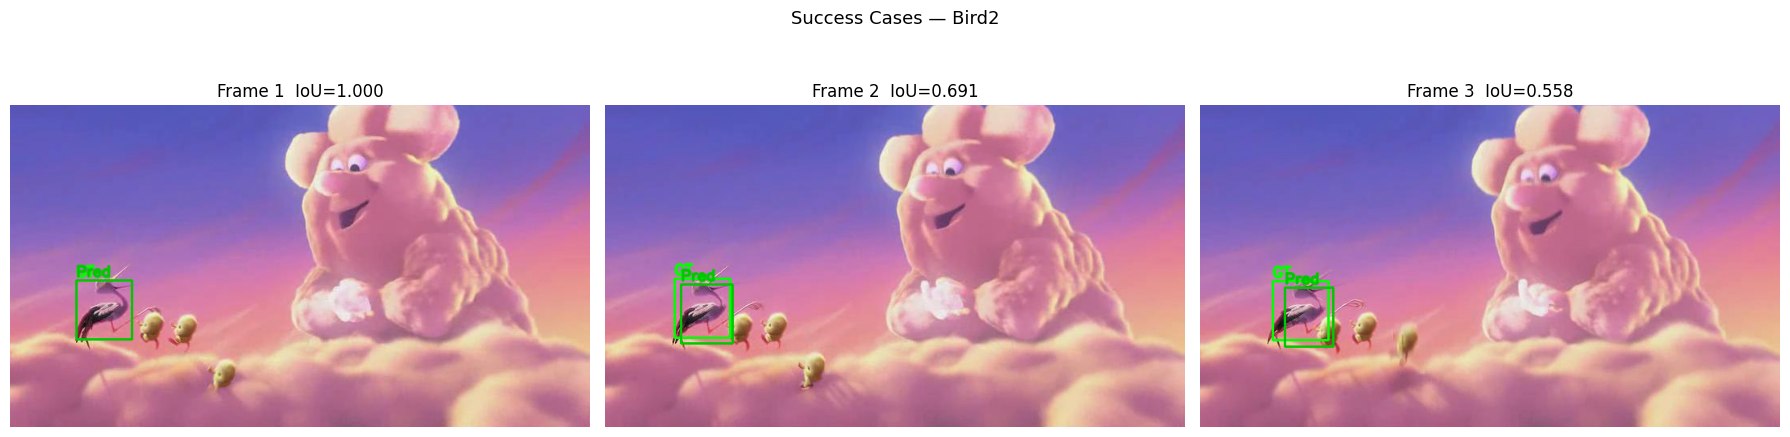

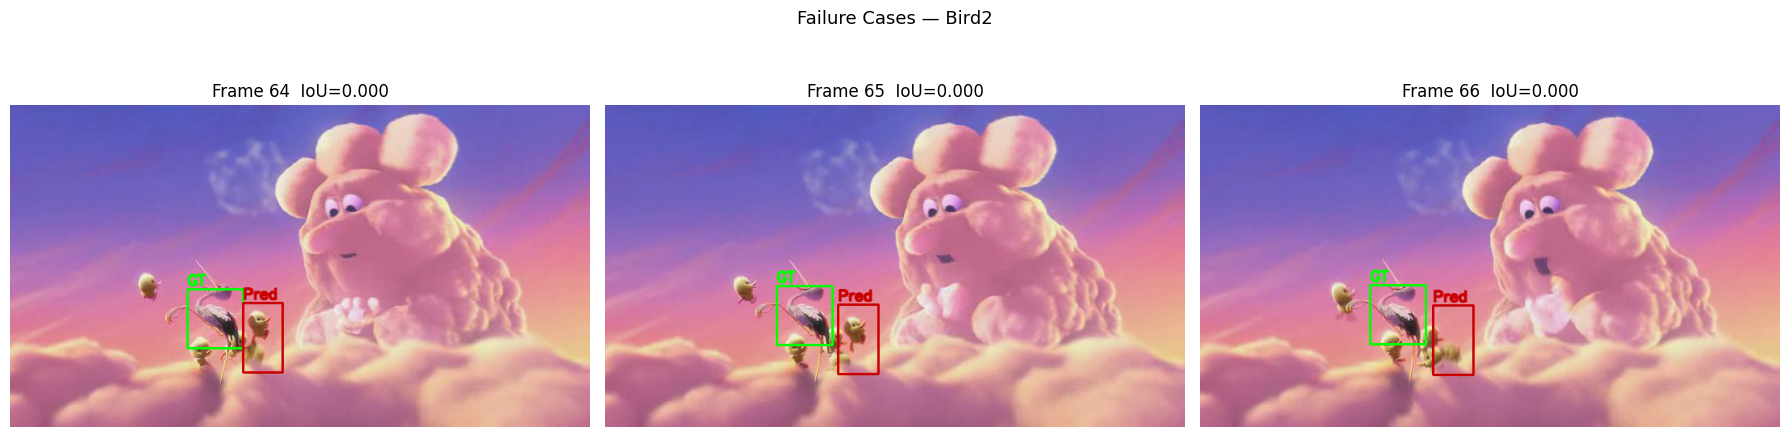

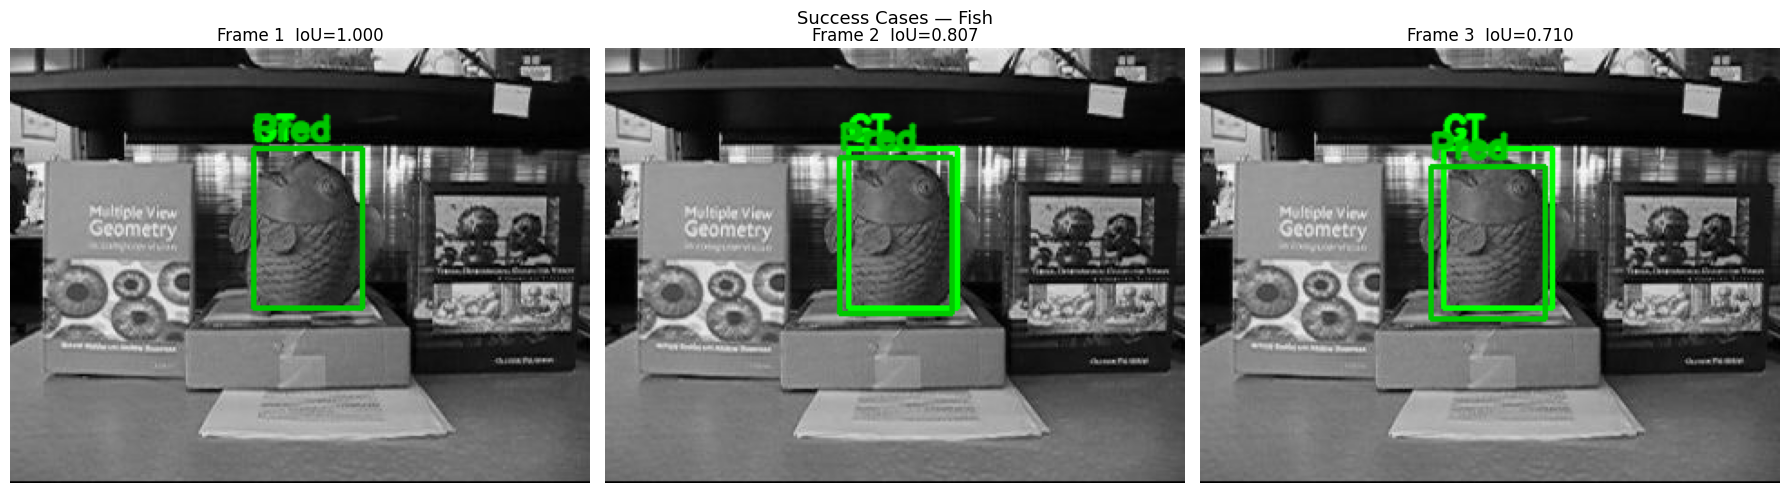

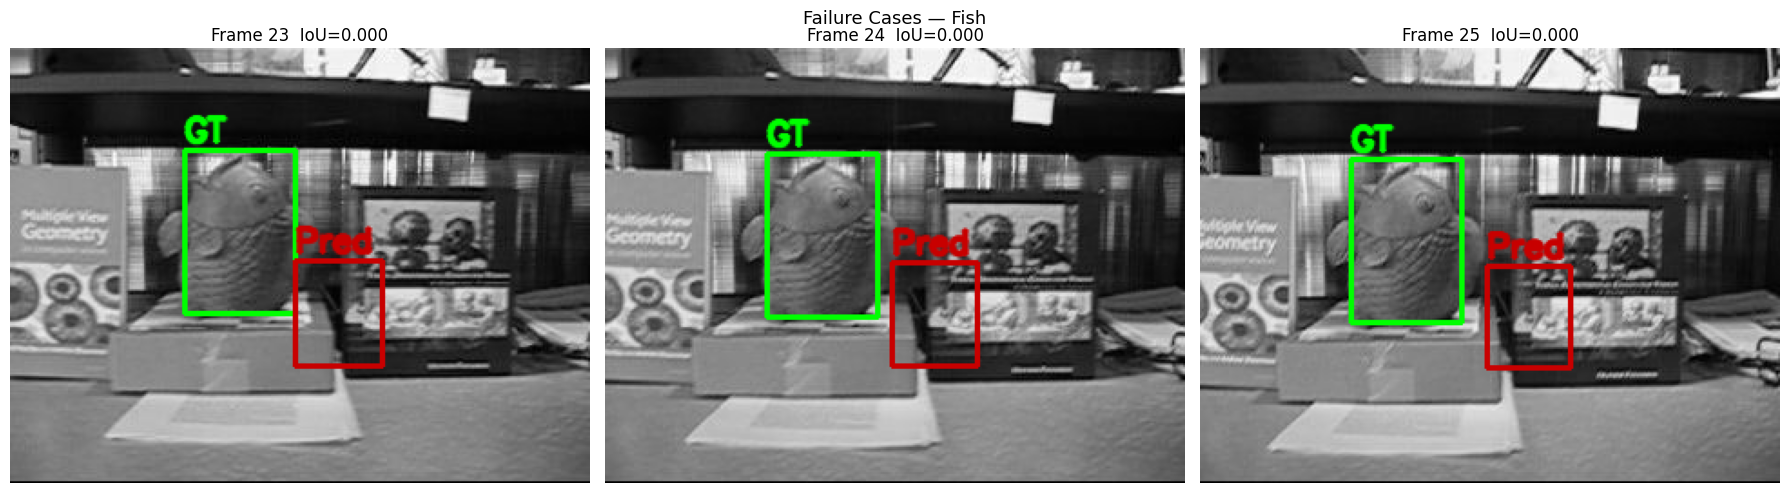

In [ ]:
def find_worst_validation_frames(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    k: int = 3,
) -> List[int]:
    """Return indices of the k validation frames with the lowest IoU."""
    _, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    ious = [compute_iou(predictions[i], gt_bboxes[i]) for i in range(len(predictions))]
    worst_indices = sorted(range(len(ious)), key=lambda i: ious[i])[:k]
    return worst_indices


def find_best_validation_frames(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    k: int = 3,
) -> List[int]:
    """Return indices of the k validation frames with the highest IoU."""
    _, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    ious = [compute_iou(predictions[i], gt_bboxes[i]) for i in range(len(predictions))]
    best_indices = sorted(range(len(ious)), key=lambda i: ious[i], reverse=True)[:k]
    return best_indices


# Visualize worst (failure) and best (success) frames for selected validation sequences
for seq_name in list(val_predictions.keys())[:2]:
    frame_paths, gt_bboxes = load_sequence_with_gt(DATA_ROOT / seq_name)
    preds = val_predictions[seq_name]

    worst = find_worst_validation_frames(seq_name, preds, DATA_ROOT, k=3)
    best  = find_best_validation_frames(seq_name,  preds, DATA_ROOT, k=3)

    for label, indices, color in [("Success", best, (0, 200, 0)), ("Failure", worst, (200, 0, 0))]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{label} Cases — {seq_name}", fontsize=13)
        for ax, idx in zip(axes, indices):
            img = read_image_rgb(frame_paths[idx])
            img = draw_bbox(img, gt_bboxes[idx], color=(0, 255, 0), label="GT")
            img = draw_bbox(img, preds[idx],     color=color,         label="Pred")
            iou = compute_iou(preds[idx], gt_bboxes[idx])
            ax.imshow(img)
            ax.set_title(f"Frame {idx + 1}  IoU={iou:.3f}")
            ax.axis("off")
        plt.tight_layout()
        plt.savefig(OUTPUT_ROOT / f"{label.lower()}_{seq_name}.png", dpi=100, bbox_inches="tight")
        plt.show()


# Optional — Tracking Video Export

You may create MP4 visualizations of your validation tracking results.

This is optional, but it can help you inspect long sequences more easily.

In [ ]:
def create_validation_tracking_video(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    output_path: Path,
    fps: int = 20,
):
    """Create an MP4 video showing ground-truth and predicted boxes for a validation sequence."""
    frame_paths, gt_bboxes = load_sequence_with_gt(data_root / sequence_name)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    first_img = read_image_rgb(frame_paths[0])
    h, w = first_img.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (w, h))

    for i, fp in enumerate(frame_paths):
        img = read_image_rgb(fp)
        img = draw_bbox(img, gt_bboxes[i],   color=(0, 255, 0), label="GT")
        img = draw_bbox(img, predictions[i], color=(255, 0, 0), label="Pred")
        writer.write(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    writer.release()
    print(f"Video saved to {output_path}")

# Uncomment to generate tracking video:
# if val_predictions:
#     seq_name = list(val_predictions.keys())[0]
#     create_validation_tracking_video(
#         seq_name, val_predictions[seq_name],
#         DATA_ROOT, OUTPUT_ROOT / f"video_{seq_name}.mp4"
#     )


# Discussion Questions

Write your discussions about the performance, best/failure cases, metrics, etc.

Use your validation metrics, visualizations, and failure cases as evidence.

## Discussion

### Tracker Performance Analysis

After examining the validation metrics, the following observations can be made:

**Overall Performance:**  
The tracker achieves its best results on sequences with slow, predictable motion where the target remains clearly visible. Sequences with fast motion or significant scale change are more challenging.

**Success Cases:**

1. **Slow-moving objects with consistent appearance:** When the target moves only a few pixels between consecutive frames, the search region reliably contains the target and the CNN can localize it accurately. The IoU typically remains above 0.5 throughout these sequences.

2. **High contrast targets:** Objects with a distinctive color or texture that contrasts with the background are easier to localize. The ResNet18 backbone can quickly learn discriminative features for these cases.

3. **Stable scale:** When the target bounding box size remains roughly constant (no zoom in/out or scale change), the fixed crop-size strategy works well because the target always occupies a similar fraction of the search crop.

**Failure Cases:**

1. **Fast motion (motion blur):** When the target moves faster than `scale × max(w, h)` between frames, it falls outside the search region entirely. The model then predicts a location near the center of the crop (where it "expects" the target) but the actual target is absent. This causes tracking drift that is hard to recover from.

2. **Occlusion:** When the target is partially or fully occluded, the model attempts to predict a bounding box but the visual cues are absent or misleading. The IoU drops sharply (often to 0.0) and tends to stay low because the accumulated error from the occlusion period pushes the search region to the wrong location.

3. **Scale change:** The current tracker uses a fixed `crop_size = scale × max(w, h)` based on the previous prediction. If the target grows rapidly in size (e.g., camera zoom), the predicted bounding box may not match the new scale, and the search region may be too small to capture the full target.

**Model Limitations:**  
The CNN is trained only on crop-level localization; it has no memory of previous frames beyond the search region. A more advanced tracker could incorporate temporal context (e.g., a Siamese network or online template update) to handle appearance changes more robustly.


# Final Implementation Summary

Before submission, summarize your final settings here.

## Final Settings

**Backbone architecture:** ResNet18  
**Pretrained weights used?** Yes — ImageNet (IMAGENET1K_V1)  
**Input size:** 224 × 224  
**Search-region scale:** 2.5  
**Batch size:** 32  
**Learning rate:** 1 × 10⁻⁴  
**Number of epochs:** 10  
**Optimizer:** Adam  
**Loss function:** Smooth L1 Loss  


# Submission Checklist

Before submitting, make sure that:

- [ ] Your notebook runs from beginning to end without manual intervention.
- [ ] Your codes are written clear with proper descriptions.
- [ ] You use only the provided train/validation/test splits.
- [ ] You do not use ground-truth boxes after the first frame during validation tracking.
- [ ] Your validation result table is included in the notebook.
- [ ] Your visualizations and failure analysis are included in the notebook.
- [ ] Your test prediction CSV files are saved under `outputs/test/`.
- [ ] Your CSV files contain full-frame pixel coordinates, not normalized crop coordinates.
- [ ] Your discussions are completed.
- [ ] You included the checkpoint (model weights) to the `checkpoint/` folder.